# Embedded ML - Lab 2.1: TensorFlow

In this lab you will learn the basics of one of the most developed and widely used ML libraries: TensorFlow. It implements many of the most important ML models and algorithms and has optimized back-ends for efficient execution on CPUs, GPUs, TPUs and other devices.

In this lab you are given some helper functions but you are expected to write most of the code and be able to explain it at a high level of abstraction and also to modify any part of it. This lab is important because a significant part of the course will use TensorFlow.

### Learning outcomes


* Explain the basic concepts associated with TensorFlow
* Use the basic workflow of TensorFlow to build a simple ML model
* Implement simple dense networks with TensorFlow and Keras
* Use some of the input handling functions of TensorFlow
* Implement a simple CNN with TensorFlow and Keras
* Implement transfer learning and fine tuning.

### TensorFlow workflow
As in general with ML, in TensorFlow you have to get or preprocess the model inputs, train the model, run inference and evaluate results.

Here you should use TensorFlow to build a dense 4-layer network to classify items in the FASHION MNIST dataset. Explore a few different hidden-layer sizes and report the accuracy achieved.

Finally, investigate how to export the model to a file and write a separate code that is able to load that model and run inference again.

In [ ]:
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
# Pre-process input dataset
train_images, test_images = train_images / 255.0, test_images / 255.0
train_labels,test_labels = to_categorical(train_labels, num_classes=10), to_categorical(test_labels, num_classes=10)
# Create the model
model1 = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])
# Compile the model
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Create the model
model2 = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])
# Compile the model
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Create the model
model3 = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(10, activation='softmax')
])
# Compile the model
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
import matplotlib.pyplot as plt
print('trainning to model 1')
history1 = model1.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels), verbose='0')
print('trainning to model 2')
history2 = model2.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels), verbose='0')
print('trainning to model 3')
history3 = model3.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels), verbose='0')

trainning to model 1
Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10
trainning to model 2
Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10
trainning to model 3
Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10


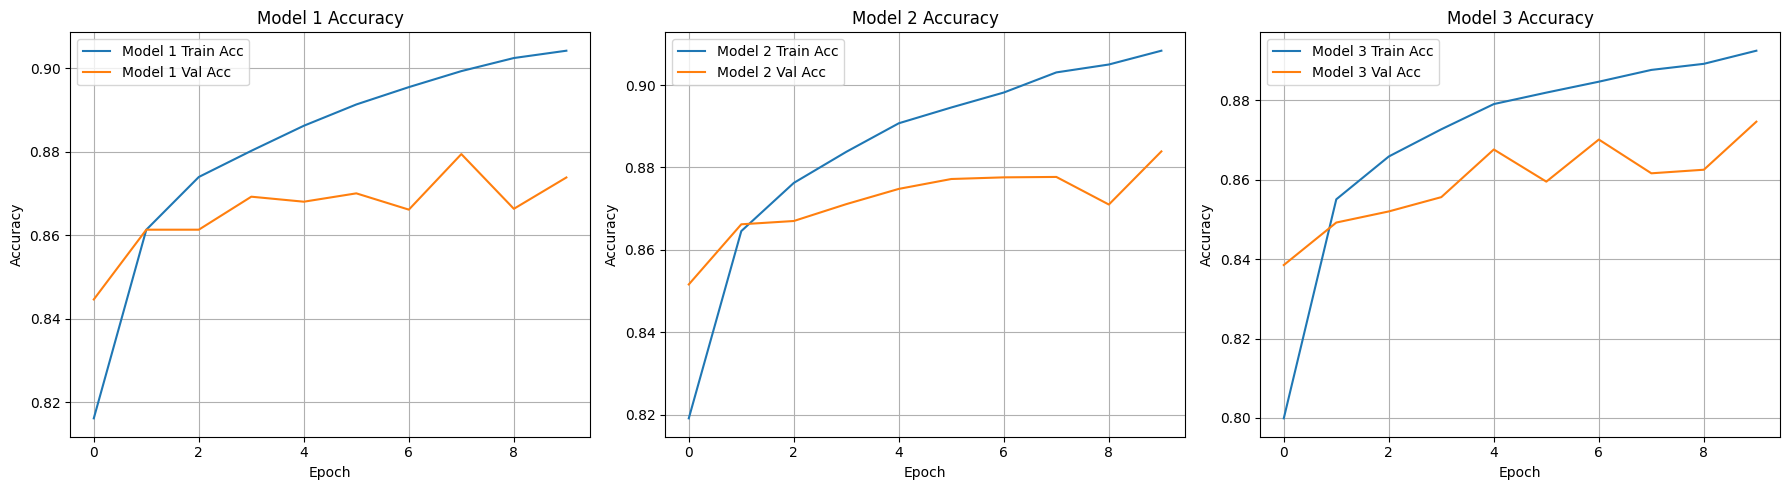

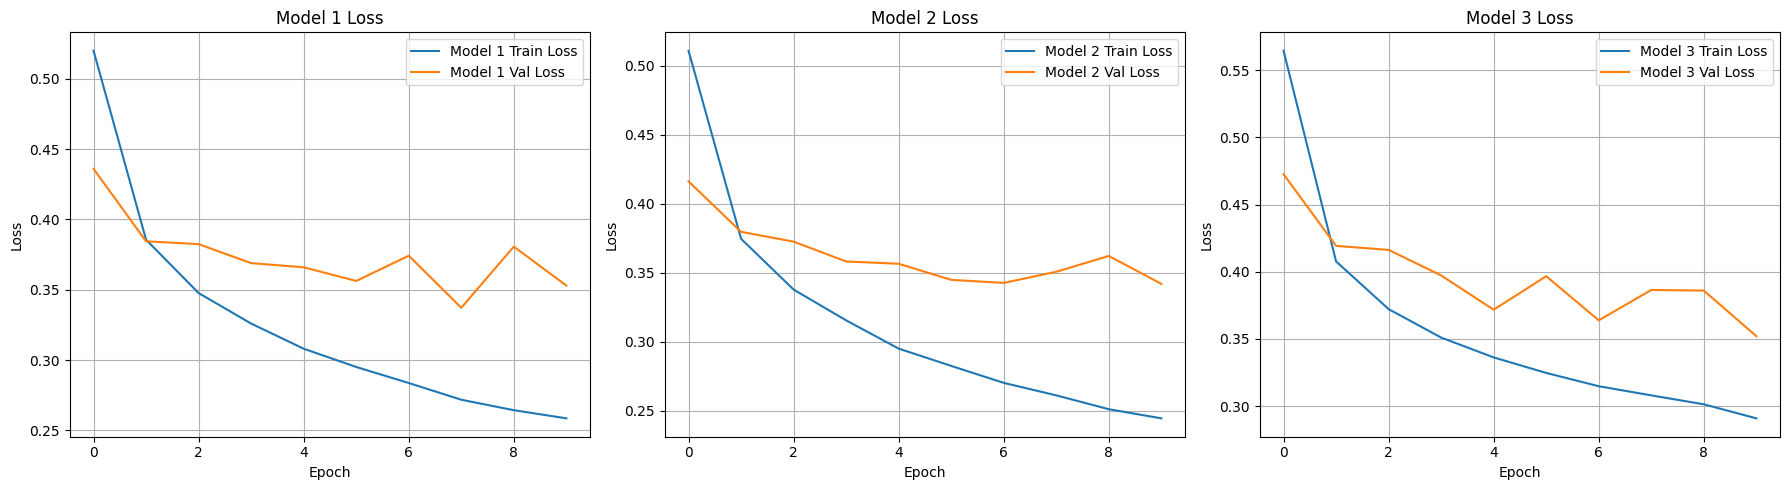

In [ ]:
import matplotlib.pyplot as plt
# Plot training and validation accuracy in 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history1.history['accuracy'], label='Model 1 Train Acc')
axes[0].plot(history1.history['val_accuracy'], label='Model 1 Val Acc')
axes[0].set_title('Model 1 Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history2.history['accuracy'], label='Model 2 Train Acc')
axes[1].plot(history2.history['val_accuracy'], label='Model 2 Val Acc')
axes[1].set_title('Model 2 Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history3.history['accuracy'], label='Model 3 Train Acc')
axes[2].plot(history3.history['val_accuracy'], label='Model 3 Val Acc')
axes[2].set_title('Model 3 Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Plot training and validation loss in 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history1.history['loss'], label='Model 1 Train Loss')
axes[0].plot(history1.history['val_loss'], label='Model 1 Val Loss')
axes[0].set_title('Model 1 Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history2.history['loss'], label='Model 2 Train Loss')
axes[1].plot(history2.history['val_loss'], label='Model 2 Val Loss')
axes[1].set_title('Model 2 Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history3.history['loss'], label='Model 3 Train Loss')
axes[2].plot(history3.history['val_loss'], label='Model 3 Val Loss')
axes[2].set_title('Model 3 Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Save the model to a file
model1.save_weights('model1.weights.h5')

In [ ]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,952 (617.00 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 105,302 (411.34 KB)

In [ ]:
# Instantiate model
# Create the model
model_instance = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

# Evaluate functional performance
model_instance.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Load the saved model
model_instance.load_weights('model1.weights.h5')
# Pre-process test inputs
#test_images = test_images / 255.0
#test_labels = to_categorical(test_labels, num_classes=10)
# Verify functional performance
model_instance.evaluate(test_images, test_labels)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8725 - loss: 0.3574


[0.35293659567832947, 0.8737999796867371]

### CNNs with TensorFlow
Convolutional Neural Networks add another type of processing layers to extract image features that allow the model to indentify patterns for a much better accuracy results in computer vision applications.

Implement a CNN model to classify the FASHION MNIST dataset and compare the accuracy results with the previous dense model. Also report a comparison of the model size measuring the saved model file size and through an analytical estimation.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8725 - loss: 0.3574
Validation Accuracy: 0.874


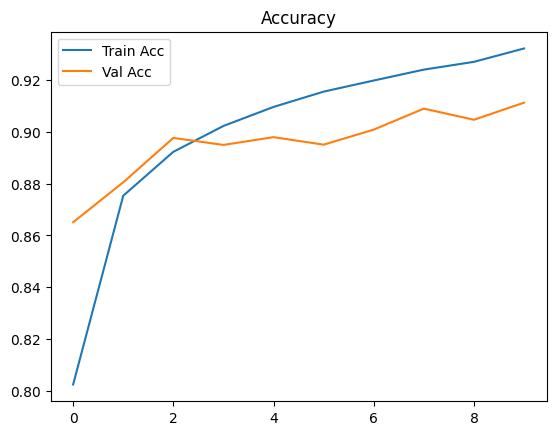

In [ ]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
# Pre-process input dataset
train_images, test_images = train_images / 255.0, test_images / 255.0
train_labels,test_labels = to_categorical(train_labels, num_classes=10), to_categorical(test_labels, num_classes=10)
# Create the CNN model
model_conv = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(16, (3, 3), activation='relu'),
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
 ])
# Compile the CNN model
model_conv.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Train the model
history_conv = model_conv.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels),verbose='0')
# Evaluate functional performance
val_loss, val_acc = model1.evaluate(test_images, test_labels)
print(f"Validation Accuracy: {val_acc:.3f}")

plt.plot(history_conv.history['accuracy'], label='Train Acc')
plt.plot(history_conv.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()
# Save the model to a file
model_conv.save_weights('model_cov.weights.h5')

In [ ]:
model_conv.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,112 (414.50 KB)

 Trainable params: 35,370 (138.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 70,742 (276.34 KB)

### Transfer learning and fine tuning
When you want to build a model but do not have enough data or resources to train a network with the accuracy you need, it possible to use a model that has been pre-trained on a large dataset and fine tune it with the target (smaller) dataset to solve the target classification problem.

Here you should use TensorFlow and Keras to download a pre-trained vision model from TensorFlow Hub (e.g. MobileNet V2), add a softmax classification layer and train it with a small subset of the Fashion MNIST dataset.

Compare runtimes and Top-1 accuracy of the resulting model with the dense and convolutional models previously built.



In [ ]:
from sklearn.model_selection import train_test_split

# Get 30% of the training data and labels
train_images_subset, _, train_labels_subset, _ = train_test_split(
    train_images, train_labels, train_size=0.5, random_state=42, stratify=train_labels)

test_images_subset, _, test_labels_subset, _ = train_test_split(
    test_images, test_labels, train_size=0.5, random_state=42, stratify=test_labels)

In [ ]:
IMG_SIZE = (64, 64) # Changed IMG_SIZE to 64x64
IMG_SHAPE = IMG_SIZE + (3,)

base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False
rescale = tf.keras.layers.Rescaling(1./127.5, offset=-1)

# build a new model adding a softmax layer
model_transfer = tf.keras.Sequential([
    rescale,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(10, activation='softmax')
])

# compile and train the new model
model_transfer.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Resize and expand dimensions of train and test images
train_images_resized = tf.repeat(tf.expand_dims(train_images_subset, axis=-1), 3, axis=-1) # Repeat channel 3 times
train_images_resized = tf.image.resize(train_images_resized, IMG_SIZE)

# Repeat the channel 3 times
test_images_resized = tf.repeat(tf.expand_dims(test_images_subset, axis=-1), 3, axis=-1) # Repeat channel 3 times
test_images_resized = tf.image.resize(test_images_resized, IMG_SIZE)

model_transfer.fit(train_images_resized, train_labels_subset, epochs=20., validation_data=(test_images_resized, test_labels_subset))

model_transfer.evaluate(test_images_resized, test_labels_subset)

<ipython-input-11-a5189c36e71d>:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,


Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 48ms/step - accuracy: 0.4193 - loss: 1.5828 - val_accuracy: 0.6474 - val_loss: 1.0771
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6474 - loss: 1.0282 - val_accuracy: 0.6624 - val_loss: 0.9557
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6776 - loss: 0.9167 - val_accuracy: 0.6424 - val_loss: 0.9553
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7006 - loss: 0.8590 - val_accuracy: 0.7118 - val_loss: 0.8275
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.7071 - loss: 0.8222 - val_accuracy: 0.7048 - val_loss: 0.8156
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7181 - loss: 0.8002 - val_accuracy: 0.7294 - val_loss: 0.7894
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7233 - loss: 0.7807 - val_accuracy: 0.7164 - val_loss: 0.7925
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7312 - loss: 0.7549 - val_accurac

[0.6874047517776489, 0.7519999742507935]

In [ ]:
model_transfer.fit(train_images_resized, train_labels_subset, epochs=20, validation_data=(test_images_resized, test_labels_subset))

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7626 - loss: 0.6527 - val_accuracy: 0.7328 - val_loss: 0.7042
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.7698 - loss: 0.6427 - val_accuracy: 0.7606 - val_loss: 0.6741
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7689 - loss: 0.6397 - val_accuracy: 0.7508 - val_loss: 0.6890
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7679 - loss: 0.6410 - val_accuracy: 0.7524 - val_loss: 0.6774
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7643 - loss: 0.6430 - val_accuracy: 0.7584 - val_loss: 0.6696
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7739 - loss: 0.6253 - val_accuracy: 0.7208 - val_loss: 0.7439
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7696 - loss: 0.6340 - val_accuracy: 0.7376 - val_loss: 0.7008
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7747 - loss: 0.6252 - val_accuracy: 